
# Working with XES Event Logs in Python

**This notebook is part of the Process Intelligence in Action (2AMI30) course**

This notebook is a hands-on introduction to the **XES (.xes) event log format**, which is widely used in **process mining**.  
You are expected to be comfortable with Python, pandas, and Jupyter notebooks.

This notebook will cover:
- Understanding the structure of an XES file (log → trace → event)
- Loading and inspecting XES files in Python
- Converting XES logs to pandas DataFrames
- Performing basic exploratory analysis on event logs

We will use the `pm4py` library, the de‑facto standard for process mining in Python.



## 1. Understanding the structure of an XES file

The **eXtensible Event Stream (XES)** format is an XML-based standard for event logs.

Conceptually, an XES log has three nested levels:

1. **Log** – the whole dataset
2. **Trace** – one process instance
3. **Event** – one step in the process

Each level can have **attributes**:
- Events typically have: `concept:name`, `time:timestamp`, `org:resource`
- Traces often have: `case_id`, `customer`, `variant`

Think of a trace as a sequence of time-ordered events describing *what happened* for a single case.



## 2. Required libraries

We use **pm4py** for reading and analyzing XES logs.

If pm4py is not installed, run the following (once):
```bash
pip install pm4py
```


In [2]:

import pm4py
import pandas as pd

from pm4py.objects.log.importer.xes import importer as xes_importer
from pm4py.objects.conversion.log import converter as log_converter



## 3. Loading an XES file

Place your `.xes` file in the same directory as this notebook, or update the path below.


In [3]:

# Update this path to your XES file
xes_path = "Supermarket_Cashier.xes"
xes_path2 = "Supermarket_Clerk.xes"
xes_path3 = "Supermarket_Counter.xes"
xes_path4 = "Supermarket_Customer.xes"
xes_path5 = "Supermarket_Manager.xes"

log_cashier = xes_importer.apply(xes_path)
log_clerk = xes_importer.apply(xes_path2)
log_counter = xes_importer.apply(xes_path3)
log_customer = xes_importer.apply(xes_path4)
log_manager = xes_importer.apply(xes_path5)



parsing log, completed traces ::   0%|          | 0/37 [00:00<?, ?it/s]

parsing log, completed traces ::   0%|          | 0/10 [00:00<?, ?it/s]

parsing log, completed traces ::   0%|          | 0/18 [00:00<?, ?it/s]

parsing log, completed traces ::   0%|          | 0/9557 [00:00<?, ?it/s]

parsing log, completed traces ::   0%|          | 0/2 [00:00<?, ?it/s]


## 4. Inspecting traces and events

An imported XES log behaves like a **list of traces**.
Each trace behaves like a **list of events**.


In [3]:

# Inspect the first trace
first_trace = log[0]

print(type(first_trace))
print(f"Number of events in first trace: {len(first_trace)}")
print("Trace attributes:")
print(first_trace.attributes)


<class 'pm4py.objects.log.obj.Trace'>
Number of events in first trace: 116
Trace attributes:
{'concept:name': '10'}


In [4]:
log[0]

{'attributes': {'concept:name': '10'}, 'events': [{'hr': 16.0, 'lifecycle:transition': 'complete', 'concept:name': 'Start Shift', 'd': 4.0, 'day': 0.0, 'time:timestamp': datetime.datetime(2026, 1, 26, 16, 0, tzinfo=datetime.timezone.utc), 'col': nan, 'q': nan, 'iMI': nan, 'mC': nan, 'mI': nan, 'iMC': nan, 'cid': nan, 'cnt': nan, 'x': nan, 'pc': nan}, '..', {'hr': nan, 'lifecycle:transition': 'complete', 'concept:name': 'End shift', 'd': nan, 'day': nan, 'time:timestamp': datetime.datetime(2026, 3, 6, 20, 0, tzinfo=datetime.timezone.utc), 'col': nan, 'q': nan, 'iMI': nan, 'mC': nan, 'mI': nan, 'iMC': nan, 'cid': nan, 'cnt': nan, 'x': 8.0, 'pc': 0.0}]}

In [5]:

# Inspect the first event of the first trace
first_event = first_trace[0]

print(type(first_event))
print(first_event)


<class 'pm4py.objects.log.obj.Event'>
{'hr': 16.0, 'lifecycle:transition': 'complete', 'concept:name': 'Start Shift', 'd': 4.0, 'day': 0.0, 'time:timestamp': datetime.datetime(2026, 1, 26, 16, 0, tzinfo=datetime.timezone.utc), 'col': nan, 'q': nan, 'iMI': nan, 'mC': nan, 'mI': nan, 'iMC': nan, 'cid': nan, 'cnt': nan, 'x': nan, 'pc': nan}



## 5. Common event attributes

Typical event attributes you should always look for:
- `concept:name` – the activity name
- `time:timestamp` – when the event occurred
- `org:resource` – who executed it (if available)

Not all logs contain all attributes.


In [6]:

# Collect all event attribute keys in the log
attribute_keys = set()

for trace in log:
    for event in trace:
        attribute_keys.update(event.keys())

attribute_keys


{'cid',
 'cnt',
 'col',
 'concept:name',
 'd',
 'day',
 'hr',
 'iMC',
 'iMI',
 'lifecycle:transition',
 'mC',
 'mI',
 'pc',
 'q',
 'time:timestamp',
 'x'}


## 6. Converting an XES log to a pandas DataFrame

For data science workflows, it is often convenient to work with a **tabular representation**.

pm4py provides a built-in conversion.


In [7]:

log_df = log_converter.apply(log, variant=log_converter.Variants.TO_DATA_FRAME)

log_df.head()


,hr,lifecycle:transition,concept:name,d,day,time:timestamp,col,q,iMI,mC,mI,iMC,cid,cnt,x,pc,case:concept:name
0,16.0,complete,Start Shift,4.0,0.0,2026-01-26 16:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10
1,NaN,complete,Open counter,4.0,NaN,2026-01-26 16:00:00+00:00,"[(0,0,0,true),(1,1,19,true),(2,0,0,true),(3,0,...","[7,8,9,10,11,12,13,14,15,16,17]",0.0,0.0,0.0,0.0,6.0,NaN,NaN,NaN,10
2,NaN,complete,Close counter,4.0,NaN,2026-01-26 20:00:00+00:00,"[(0,2,92,true),(1,0,0,false),(2,1,5,true),(3,2...","[4,5,1,12,13,14,15,16,17]",7.0,0.0,0.0,9.0,6.0,17.0,40.0,NaN,10
3,NaN,complete,End shift,NaN,NaN,2026-01-26 20:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.0,NaN,10
4,16.0,complete,Start Shift,4.0,1.0,2026-01-27 16:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10



### Interpreting the DataFrame

Typical columns:
- `case:concept:name` → case ID
- `concept:name` → activity
- `time:timestamp` → event time

Each row corresponds to **one event**.
Multiple rows with the same case ID form a trace.



## 7. Basic exploratory analysis


In [8]:

# Number of events
len(log_df)


2928

In [9]:

# Number of unique cases
log_df['case:concept:name'].nunique()


37

In [10]:

# Most frequent activities
log_df['concept:name'].value_counts().head(10)


concept:name
Start Shift      732
Open counter     732
Close counter    732
End shift        732
Name: count, dtype: int64

In [11]:

# Trace length distribution
trace_lengths = log_df.groupby('case:concept:name').size()
trace_lengths.describe()


count     37.000000
mean      79.135135
std       72.130346
min       20.000000
25%       28.000000
50%       40.000000
75%      112.000000
max      240.000000
dtype: float64


## 8. Event ordering and timestamps

Event order **must always be derived from timestamps**, not row order.


In [12]:

# Ensure correct ordering
log_df_sorted = log_df.sort_values(
    ['case:concept:name', 'time:timestamp']
)

log_df_sorted.head()


,hr,lifecycle:transition,concept:name,d,day,time:timestamp,col,q,iMI,mC,mI,iMC,cid,cnt,x,pc,case:concept:name
0,16.0,complete,Start Shift,4.0,0.0,2026-01-26 16:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10
1,NaN,complete,Open counter,4.0,NaN,2026-01-26 16:00:00+00:00,"[(0,0,0,true),(1,1,19,true),(2,0,0,true),(3,0,...","[7,8,9,10,11,12,13,14,15,16,17]",0.0,0.0,0.0,0.0,6.0,NaN,NaN,NaN,10
2,NaN,complete,Close counter,4.0,NaN,2026-01-26 20:00:00+00:00,"[(0,2,92,true),(1,0,0,false),(2,1,5,true),(3,2...","[4,5,1,12,13,14,15,16,17]",7.0,0.0,0.0,9.0,6.0,17.0,40.0,NaN,10
3,NaN,complete,End shift,NaN,NaN,2026-01-26 20:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.0,NaN,10
4,16.0,complete,Start Shift,4.0,1.0,2026-01-27 16:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10


## 9. Computing case duration

Case duration is the time between the first and last event of a case (trace).
This is one of the most basic but informative performance indicators.

In [13]:
# Compute case start and end times
case_times = (
    log_df_sorted
    .groupby('case:concept:name')['time:timestamp']
    .agg(['min', 'max'])
)

# Compute duration in seconds
case_times['duration_seconds'] = (
    case_times['max'] - case_times['min']
).dt.total_seconds()

case_times.head()

,min,max,duration_seconds
case:concept:name,,,
10,2026-01-26 16:00:00+00:00,2026-03-06 20:00:00+00:00,3384000.000
13,2026-01-27 18:00:00+00:00,2026-03-04 22:05:29.135000+00:00,3125129.135
14,2026-01-27 18:00:00+00:00,2026-03-04 22:05:29.135000+00:00,3125129.135
15,2026-01-27 18:00:00+00:00,2026-03-04 22:05:29.135000+00:00,3125129.135
18,2026-01-26 17:00:00+00:00,2026-03-06 20:00:00+00:00,3380400.000


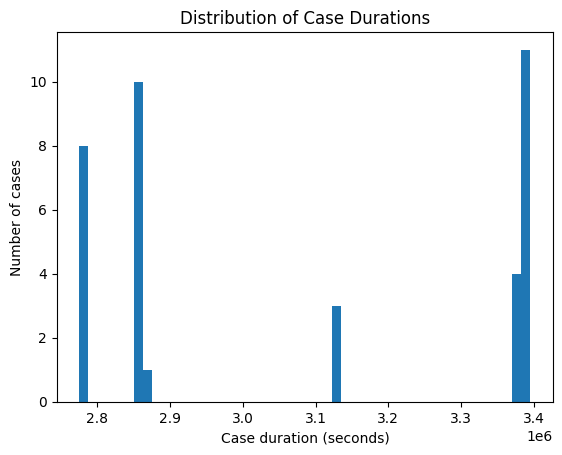

In [14]:
# Plot case duration histogram
import matplotlib.pyplot as plt

plt.hist(case_times['duration_seconds'], bins=50)
plt.xlabel("Case duration (seconds)")
plt.ylabel("Number of cases")
plt.title("Distribution of Case Durations")
plt.show()

## 10. Variants: identifying execution paths

A variant is a unique sequence of activities executed by a case.
Variants are essential for understanding process complexity and deviations.

In [15]:
# Build activity sequences per case
variants = (
    log_df_sorted
    .groupby('case:concept:name')['concept:name']
    .apply(tuple)
)

variants.head()

case:concept:name
10    (Start Shift, Open counter, Close counter, End...
13    (Start Shift, Open counter, Close counter, End...
14    (Start Shift, Open counter, Close counter, End...
15    (Start Shift, Open counter, Close counter, End...
18    (Start Shift, Open counter, Close counter, End...
Name: concept:name, dtype: object

In [16]:
# Count variant frequencies
variant_counts = variants.value_counts().reset_index()
variant_counts.columns = ['variant', 'frequency']

variant_counts.head(10)


,variant,frequency
0,"(Start Shift, Open counter, Close counter, End...",10
1,"(Start Shift, Open counter, Close counter, End...",5
2,"(Start Shift, Open counter, Close counter, End...",4
3,"(Start Shift, Open counter, Close counter, End...",4
4,"(Start Shift, Open counter, Close counter, End...",4
5,"(Start Shift, Open counter, Close counter, End...",3
6,"(Start Shift, Open counter, Close counter, End...",2
7,"(Start Shift, Open counter, Close counter, End...",2
8,"(Start Shift, Open counter, Close counter, End...",2
9,"(Start Shift, Open counter, Close counter, End...",1


## 11. Activity frequency analysis

Activity frequencies provide a first structural view of the process.

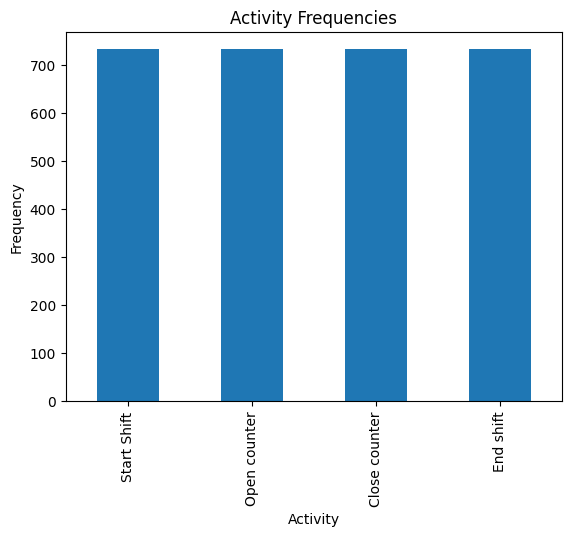

In [17]:
# Bar chart of activity frequencies
activity_counts = log_df['concept:name'].value_counts()

activity_counts.plot(kind='bar')
plt.xlabel("Activity")
plt.ylabel("Frequency")
plt.title("Activity Frequencies")
plt.show()


## 12. Temporal analysis: arrivals over time

Event logs often exhibit strong temporal patterns:

- business hours
- daily/weekly seasonality
- batching effects

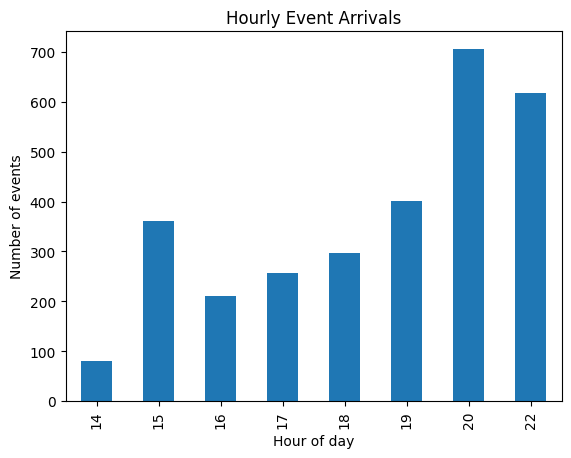

In [18]:
# Hourly arrivals
log_df['hour'] = log_df['time:timestamp'].dt.hour

hourly_arrivals = log_df.groupby('hour').size()

hourly_arrivals.plot(kind='bar')
plt.xlabel("Hour of day")
plt.ylabel("Number of events")
plt.title("Hourly Event Arrivals")
plt.show()

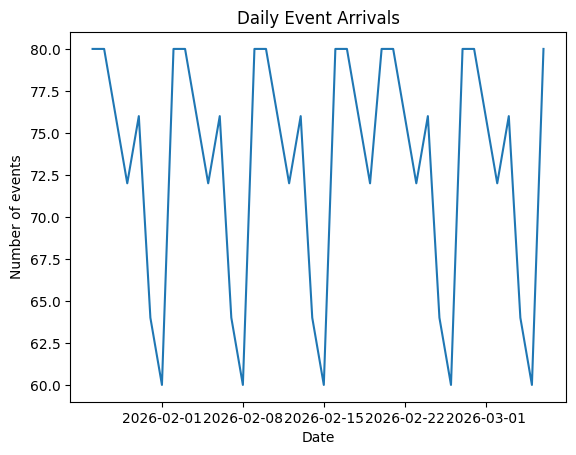

In [19]:
# Daily arrivals
log_df['date'] = log_df['time:timestamp'].dt.date

daily_arrivals = log_df.groupby('date').size()

daily_arrivals.plot()
plt.xlabel("Date")
plt.ylabel("Number of events")
plt.title("Daily Event Arrivals")
plt.show()


## 13. Dotted chart (process timeline visualization)

A dotted chart visualizes:

- x-axis → time
- y-axis → cases
- dots → events, colored by activity

This reveals concurrency, batching, and bottlenecks.

In [20]:
import seaborn as sns

In [21]:

start = pd.Timestamp("2026-01-26 14:00:00", tz="UTC")
end   = pd.Timestamp("2026-01-26 15:00:00", tz="UTC")

log_df_day = log_df[
    (log_df['time:timestamp'] >= start) &
    (log_df['time:timestamp'] < end)
]



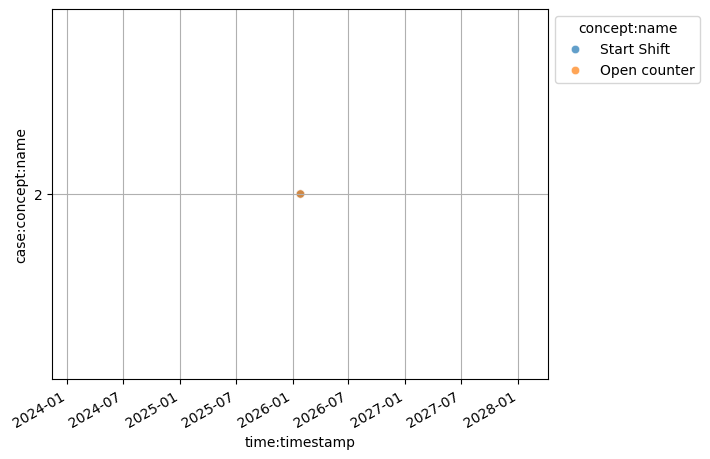

In [22]:
dotted_chart = sns.scatterplot(log_df_day.sort_values(by="time:timestamp"), x='time:timestamp', y='case:concept:name', hue='concept:name', alpha=.7)
sns.move_legend(dotted_chart, "upper left", bbox_to_anchor=(1, 1))
plt.xticks(rotation=30, ha="right")
plt.grid()
dotted_chart;

## 14. Process discovery with pm4py

**Process discovery** automatically derives a process model from event data.
We start with the **Directly-Follows Graph (DFG)** and discover a **Petri net**.

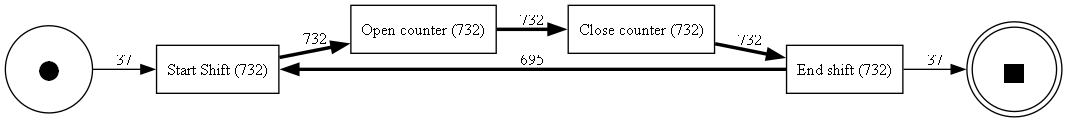

In [23]:
# Discover and visualize DFG
dfg, start_activities, end_activities = pm4py.discover_dfg(log)

pm4py.view_dfg(dfg, start_activities, end_activities)


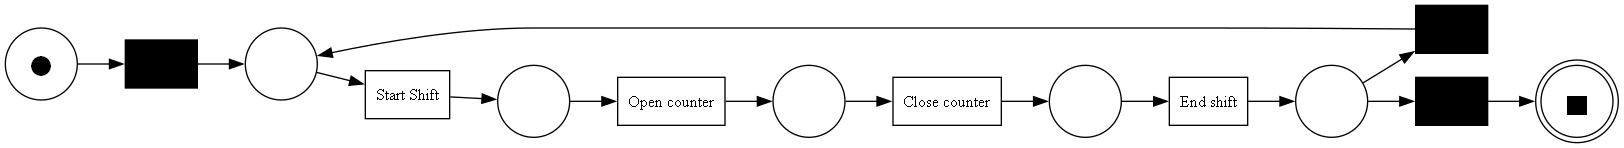

In [24]:
# Discover a Petri net (Inductive Miner)
net, initial_marking, final_marking = pm4py.discover_petri_net_inductive(log)

pm4py.view_petri_net(net, initial_marking, final_marking)

In [4]:
df_cashier = log_converter.apply(log_cashier, variant=log_converter.Variants.TO_DATA_FRAME)
df_clerk = log_converter.apply(log_clerk, variant=log_converter.Variants.TO_DATA_FRAME)
df_counter = log_converter.apply(log_counter, variant=log_converter.Variants.TO_DATA_FRAME)
df_customer = log_converter.apply(log_customer, variant=log_converter.Variants.TO_DATA_FRAME)
df_manager = log_converter.apply(log_manager, variant=log_converter.Variants.TO_DATA_FRAME)

# Ensure chronological ordering for all
print("Sorting DataFrames...")
df_cashier = df_cashier.sort_values(['case:concept:name', 'time:timestamp'])
df_clerk = df_clerk.sort_values(['case:concept:name', 'time:timestamp'])
df_counter = df_counter.sort_values(['case:concept:name', 'time:timestamp'])
df_customer = df_customer.sort_values(['case:concept:name', 'time:timestamp'])
df_manager = df_manager.sort_values(['case:concept:name', 'time:timestamp'])

Sorting DataFrames...


In [5]:
print(df_customer['concept:name'] == 'Abandon cart and leave')

0          False
1          False
2          False
3          False
4          False
           ...  
2441065    False
2441066    False
2441067    False
2441068    False
2441069    False
Name: concept:name, Length: 2441070, dtype: bool


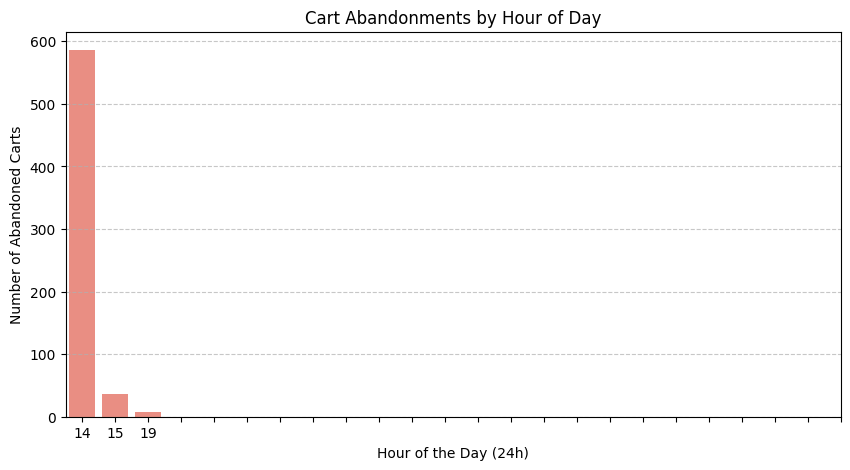

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Filter for abandonment events
abandonments = df_customer[df_customer['concept:name'] == 'Abandon cart and leave'].copy()

# 2. Extract the hour of the day from the timestamp
abandonments['hour'] = abandonments['time:timestamp'].dt.hour

# 3. Count abandonments per hour
hourly_abandonments = abandonments.groupby('hour').size().reset_index(name='abandonment_count')

# 4. Visualize the spikes
plt.figure(figsize=(10, 5))
sns.barplot(data=hourly_abandonments, x='hour', y='abandonment_count', color='salmon')
plt.title('Cart Abandonments by Hour of Day')
plt.xlabel('Hour of the Day (24h)')
plt.ylabel('Number of Abandoned Carts')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(range(0, 24)) # Ensure all 24 hours are shown if needed
plt.show()

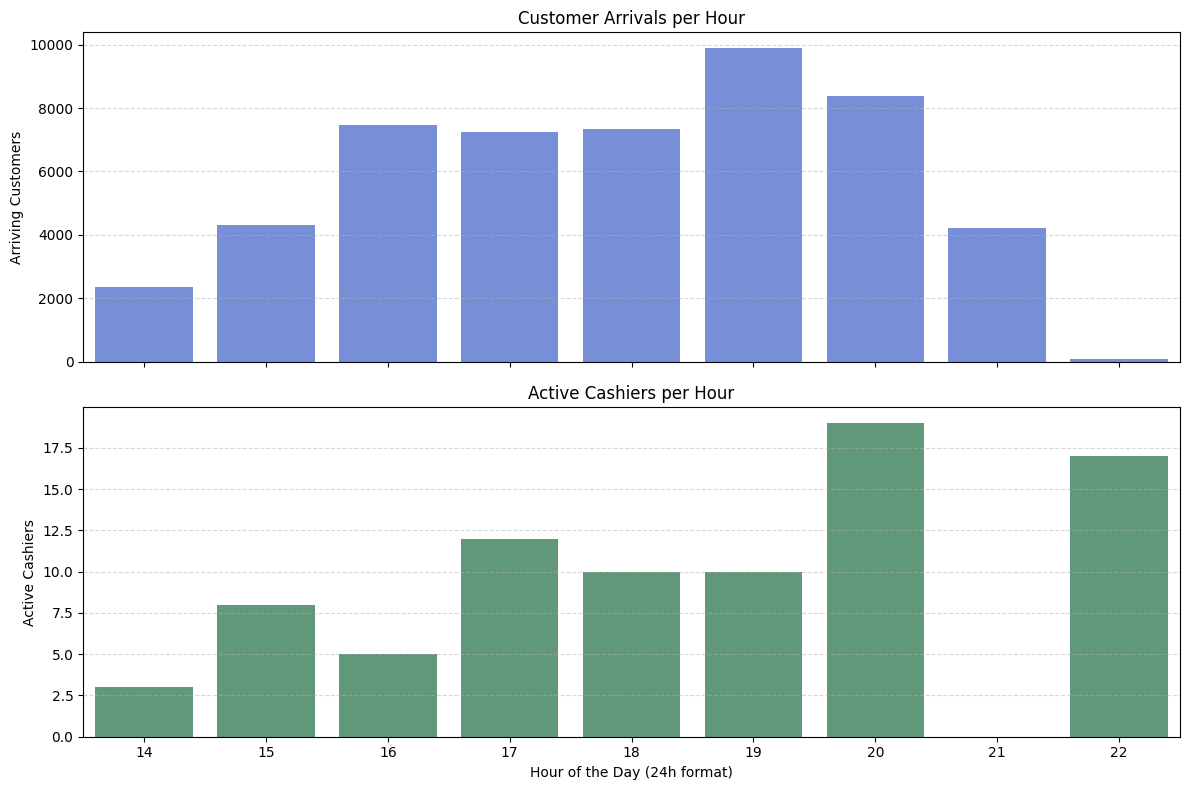

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Customer Arrivals 
# Using .str.contains to safely catch 'Enter store', 'enter store', etc.
arrivals = df_customer[df_customer['concept:name'].str.contains('Enter', case=False, na=False)].copy()
arrivals['hour'] = arrivals['time:timestamp'].dt.hour
hourly_arrivals = arrivals.groupby('hour').size().reset_index(name='customer_arrivals')

# 2. Cashier Activity (Robust method)
# Instead of looking for a specific event, we count how many unique cashiers are generating events each hour
df_cashier_copy = df_cashier.copy()
df_cashier_copy['hour'] = df_cashier_copy['time:timestamp'].dt.hour
hourly_cashiers = df_cashier_copy.groupby('hour')['case:concept:name'].nunique().reset_index(name='active_cashiers')

# 3. Merge the two datasets
mismatch_df = pd.merge(hourly_arrivals, hourly_cashiers, on='hour', how='outer').fillna(0).sort_values('hour')

# 4. Visualize with two clear, stacked subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Top chart: Customer Arrivals
sns.barplot(data=mismatch_df, x='hour', y='customer_arrivals', ax=ax1, color='royalblue', alpha=0.8)
ax1.set_title('Customer Arrivals per Hour')
ax1.set_ylabel('Arriving Customers')
ax1.grid(axis='y', linestyle='--', alpha=0.5)

# Bottom chart: Active Cashiers
sns.barplot(data=mismatch_df, x='hour', y='active_cashiers', ax=ax2, color='seagreen', alpha=0.8)
ax2.set_title('Active Cashiers per Hour')
ax2.set_xlabel('Hour of the Day (24h format)')
ax2.set_ylabel('Active Cashiers')
ax2.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

1. Finding abandoned carts...
2. Extracting the correct timestamps...
3. Calculating exact wait times...
----------------------------------------
Successfully calculated wait times for 270 abandoned carts.
The average time spent deciding to abandon the cart is: 4.17 minutes.
----------------------------------------


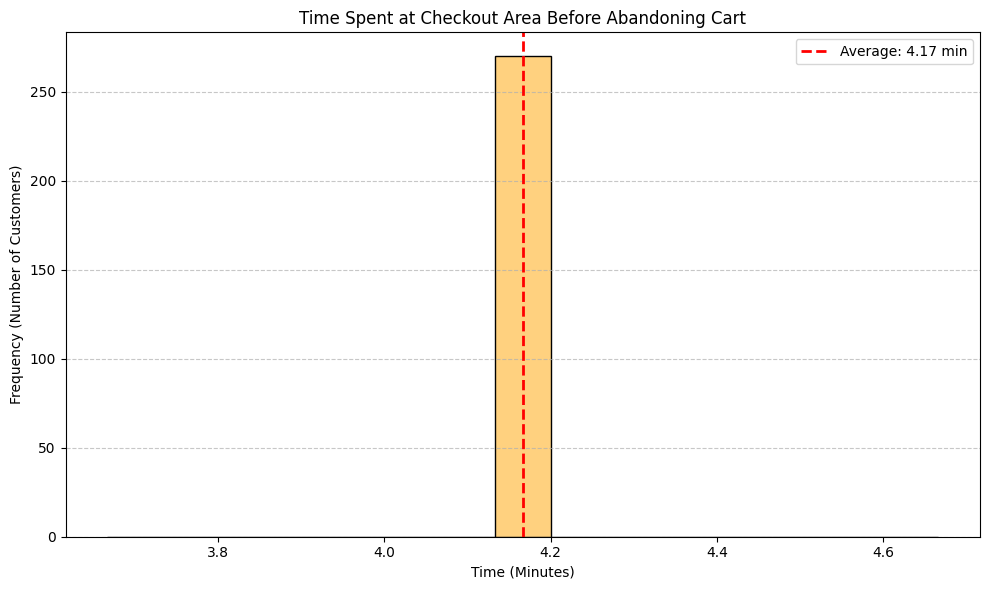

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("1. Finding abandoned carts...")
# Find the Case IDs of the 190 customers who abandoned their carts
abandoned_cases = df_customer[df_customer['concept:name'] == 'Abandon cart and leave']['case:concept:name'].unique()

# Filter the dataframe to only include traces of those specific customers
abandoned_traces = df_customer[df_customer['case:concept:name'].isin(abandoned_cases)].copy()

print("2. Extracting the correct timestamps...")
# Get the LATEST 'Go to Checkout' timestamp for each of these customers
checkouts = abandoned_traces[abandoned_traces['concept:name'] == 'Go to Checkout'].groupby('case:concept:name')['time:timestamp'].max()

# Get the LATEST 'Abandon cart and leave' timestamp for each of these customers
abandons = abandoned_traces[abandoned_traces['concept:name'] == 'Abandon cart and leave'].groupby('case:concept:name')['time:timestamp'].max()

print("3. Calculating exact wait times...")
# Combine them into a single table side-by-side
wait_times = pd.DataFrame({'checkout_time': checkouts, 'abandon_time': abandons}).dropna()

# Calculate duration in minutes
wait_times['wait_time_minutes'] = (wait_times['abandon_time'] - wait_times['checkout_time']).dt.total_seconds() / 60.0

# Apply the sanity filter to remove any leftover simulation loop artifacts (keep 0 to 120 mins)
wait_times_clean = wait_times[(wait_times['wait_time_minutes'] >= 0) & (wait_times['wait_time_minutes'] <= 120)].copy()

average_wait = wait_times_clean['wait_time_minutes'].mean()

print("-" * 40)
print(f"Successfully calculated wait times for {len(wait_times_clean)} abandoned carts.")
print(f"The average time spent deciding to abandon the cart is: {average_wait:.2f} minutes.")
print("-" * 40)

# 4. Visualize the distribution
if not wait_times_clean.empty:
    plt.figure(figsize=(10, 6))
    sns.histplot(wait_times_clean['wait_time_minutes'], bins=15, kde=True, color='orange', edgecolor='black')

    if not pd.isna(average_wait):
        plt.axvline(average_wait, color='red', linestyle='dashed', linewidth=2, label=f'Average: {average_wait:.2f} min')

    plt.title('Time Spent at Checkout Area Before Abandoning Cart')
    plt.xlabel('Time (Minutes)')
    plt.ylabel('Frequency (Number of Customers)')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("No valid wait times found. Check your log structure!")

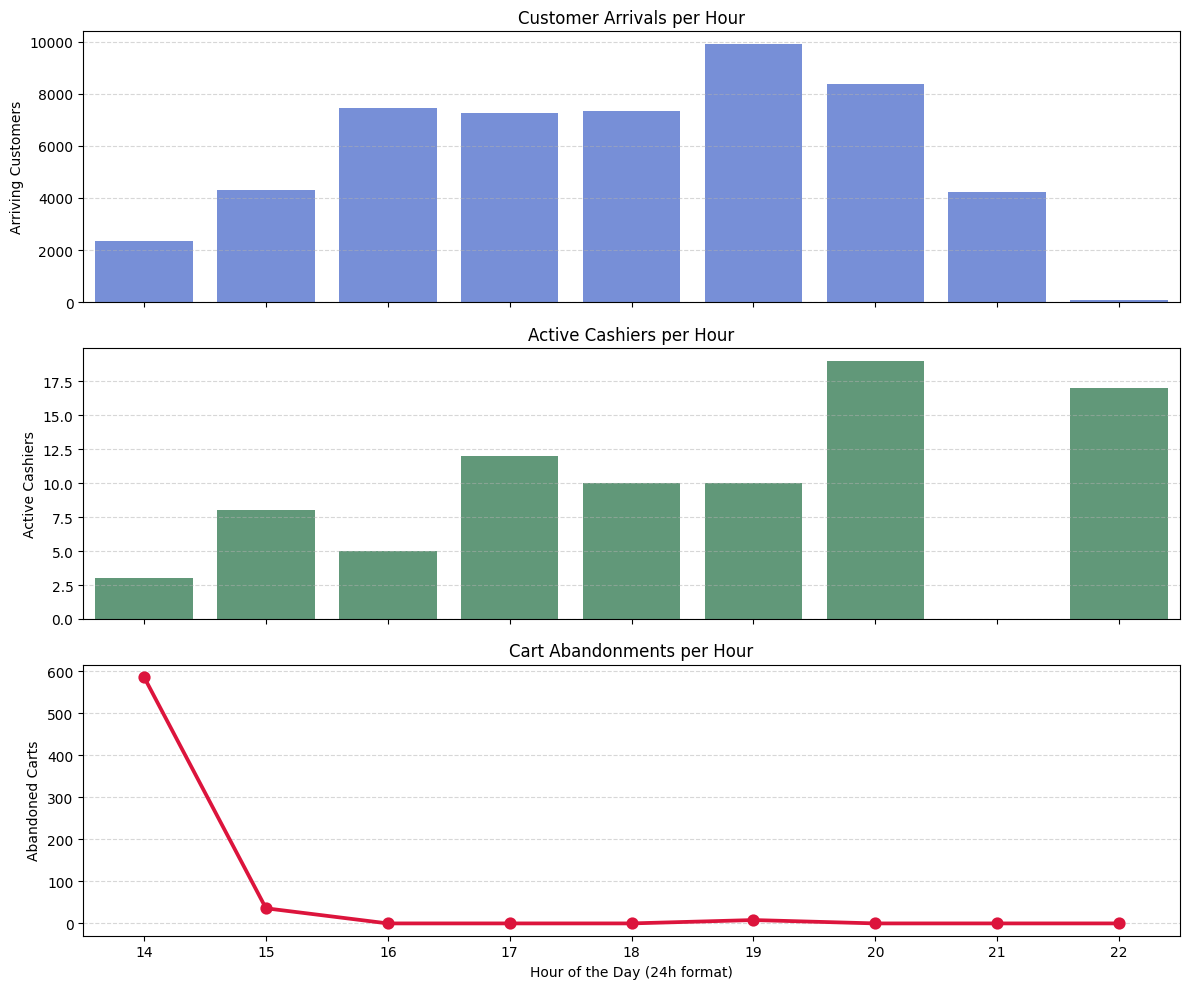

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Processing Customer Arrivals
arrivals = df_customer[df_customer['concept:name'].str.contains('Enter', case=False, na=False)].copy()
arrivals['hour'] = arrivals['time:timestamp'].dt.hour
hourly_arrivals = arrivals.groupby('hour').size().reset_index(name='customer_arrivals')

# 2. Processing Active Cashiers
df_cashier_copy = df_cashier.copy()
df_cashier_copy['hour'] = df_cashier_copy['time:timestamp'].dt.hour
hourly_cashiers = df_cashier_copy.groupby('hour')['case:concept:name'].nunique().reset_index(name='active_cashiers')

# 3. Processing Abandonments
abandonments = df_customer[df_customer['concept:name'] == 'Abandon cart and leave'].copy()
abandonments['hour'] = abandonments['time:timestamp'].dt.hour
hourly_abandonments = abandonments.groupby('hour').size().reset_index(name='abandonment_count')

# 4. Merging all three datasets
mismatch_df = pd.merge(hourly_arrivals, hourly_cashiers, on='hour', how='outer')
mismatch_df = pd.merge(mismatch_df, hourly_abandonments, on='hour', how='outer').fillna(0).sort_values('hour')

# 5. Visualize with 3 stacked subplots
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# Top chart: Customer Arrivals
sns.barplot(data=mismatch_df, x='hour', y='customer_arrivals', ax=ax1, color='royalblue', alpha=0.8)
ax1.set_title('Customer Arrivals per Hour')
ax1.set_ylabel('Arriving Customers')
ax1.grid(axis='y', linestyle='--', alpha=0.5)

# Middle chart: Active Cashiers
sns.barplot(data=mismatch_df, x='hour', y='active_cashiers', ax=ax2, color='seagreen', alpha=0.8)
ax2.set_title('Active Cashiers per Hour')
ax2.set_ylabel('Active Cashiers')
ax2.grid(axis='y', linestyle='--', alpha=0.5)

# Bottom chart: Abandonment Count (CHANGED TO POINTPLOT)
sns.pointplot(data=mismatch_df, x='hour', y='abandonment_count', ax=ax3, color='crimson')
ax3.set_title('Cart Abandonments per Hour')
ax3.set_xlabel('Hour of the Day (24h format)')
ax3.set_ylabel('Abandoned Carts')
ax3.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Average checkout time WITHOUT price check: 3.97 minutes
Average checkout time WITH price check:    5.72 minutes
-> A price check delays a customer's total checkout by an average of 1.75 minutes!


C:\Users\wesse\AppData\Local\Temp\ipykernel_2044\1654536131.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=checkout_df, x='Had Price Check', y='total_duration_mins', palette=['#4C72B0', '#DD8452'])


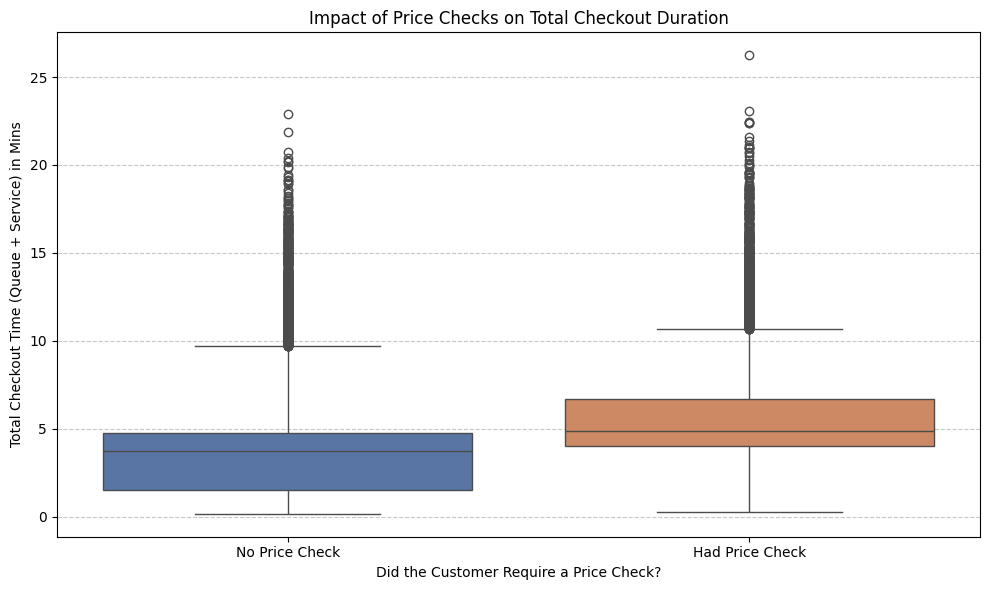

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Get the start (Enter Queue) and end (Complete Payment) times per customer at the counter
# We group by the specific counter ('case:concept:name') and the specific customer ('id')
enters = df_counter[df_counter['concept:name'] == 'Enter Queue'].groupby(['case:concept:name', 'id'])['time:timestamp'].max()
completes = df_counter[df_counter['concept:name'] == 'Complete Payment'].groupby(['case:concept:name', 'id'])['time:timestamp'].max()

checkout_df = pd.DataFrame({'enter_time': enters, 'complete_time': completes}).dropna()

# Calculate total checkout duration in minutes
checkout_df['total_duration_mins'] = (checkout_df['complete_time'] - checkout_df['enter_time']).dt.total_seconds() / 60.0

# Sanity filter (Keep 0 to 120 mins)
checkout_df = checkout_df[(checkout_df['total_duration_mins'] >= 0) & (checkout_df['total_duration_mins'] <= 120)].copy()

# 2. Flag the customers who required a price check
# Find the MultiIndex keys (Counter ID, Customer ID) for anyone who had a 'Start Price Check' event
price_check_keys = df_counter[df_counter['concept:name'] == 'Start Price Check'].set_index(['case:concept:name', 'id']).index.unique()

# Add a True/False column if the customer's ID is in the price check list
checkout_df['Had Price Check'] = checkout_df.index.isin(price_check_keys)

# 3. Calculate the delay
avg_without = checkout_df[checkout_df['Had Price Check'] == False]['total_duration_mins'].mean()
avg_with = checkout_df[checkout_df['Had Price Check'] == True]['total_duration_mins'].mean()

delay_mins = avg_with - avg_without

print(f"Average checkout time WITHOUT price check: {avg_without:.2f} minutes")
print(f"Average checkout time WITH price check:    {avg_with:.2f} minutes")
print(f"-> A price check delays a customer's total checkout by an average of {delay_mins:.2f} minutes!")

# 4. Visualize the systemic impact
plt.figure(figsize=(10, 6))
# A Boxplot is perfect here to show how the distribution of time shifts when a price check is involved
sns.boxplot(data=checkout_df, x='Had Price Check', y='total_duration_mins', palette=['#4C72B0', '#DD8452'])

plt.title('Impact of Price Checks on Total Checkout Duration')
plt.xlabel('Did the Customer Require a Price Check?')
plt.ylabel('Total Checkout Time (Queue + Service) in Mins')
plt.xticks(ticks=[0, 1], labels=['No Price Check', 'Had Price Check'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Generating DFG for: Cashier Perspective
File: Supermarket_Cashier.xes


parsing log, completed traces ::   0%|          | 0/37 [00:00<?, ?it/s]

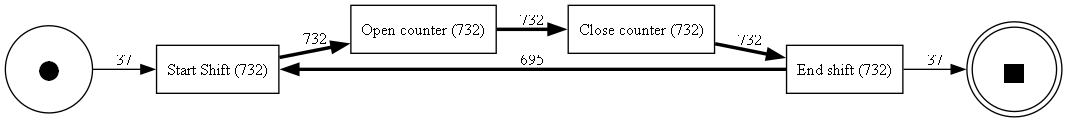

Generating DFG for: Clerk Perspective
File: Supermarket_Clerk.xes


parsing log, completed traces ::   0%|          | 0/10 [00:00<?, ?it/s]

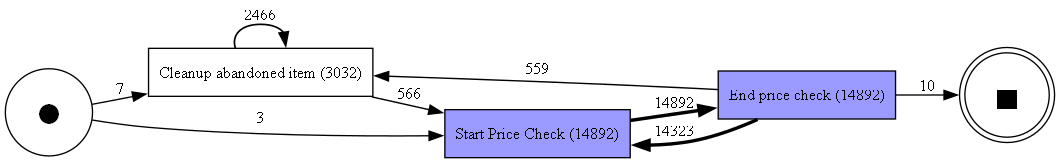

Generating DFG for: Counter Perspective
File: Supermarket_Counter.xes


parsing log, completed traces ::   0%|          | 0/18 [00:00<?, ?it/s]

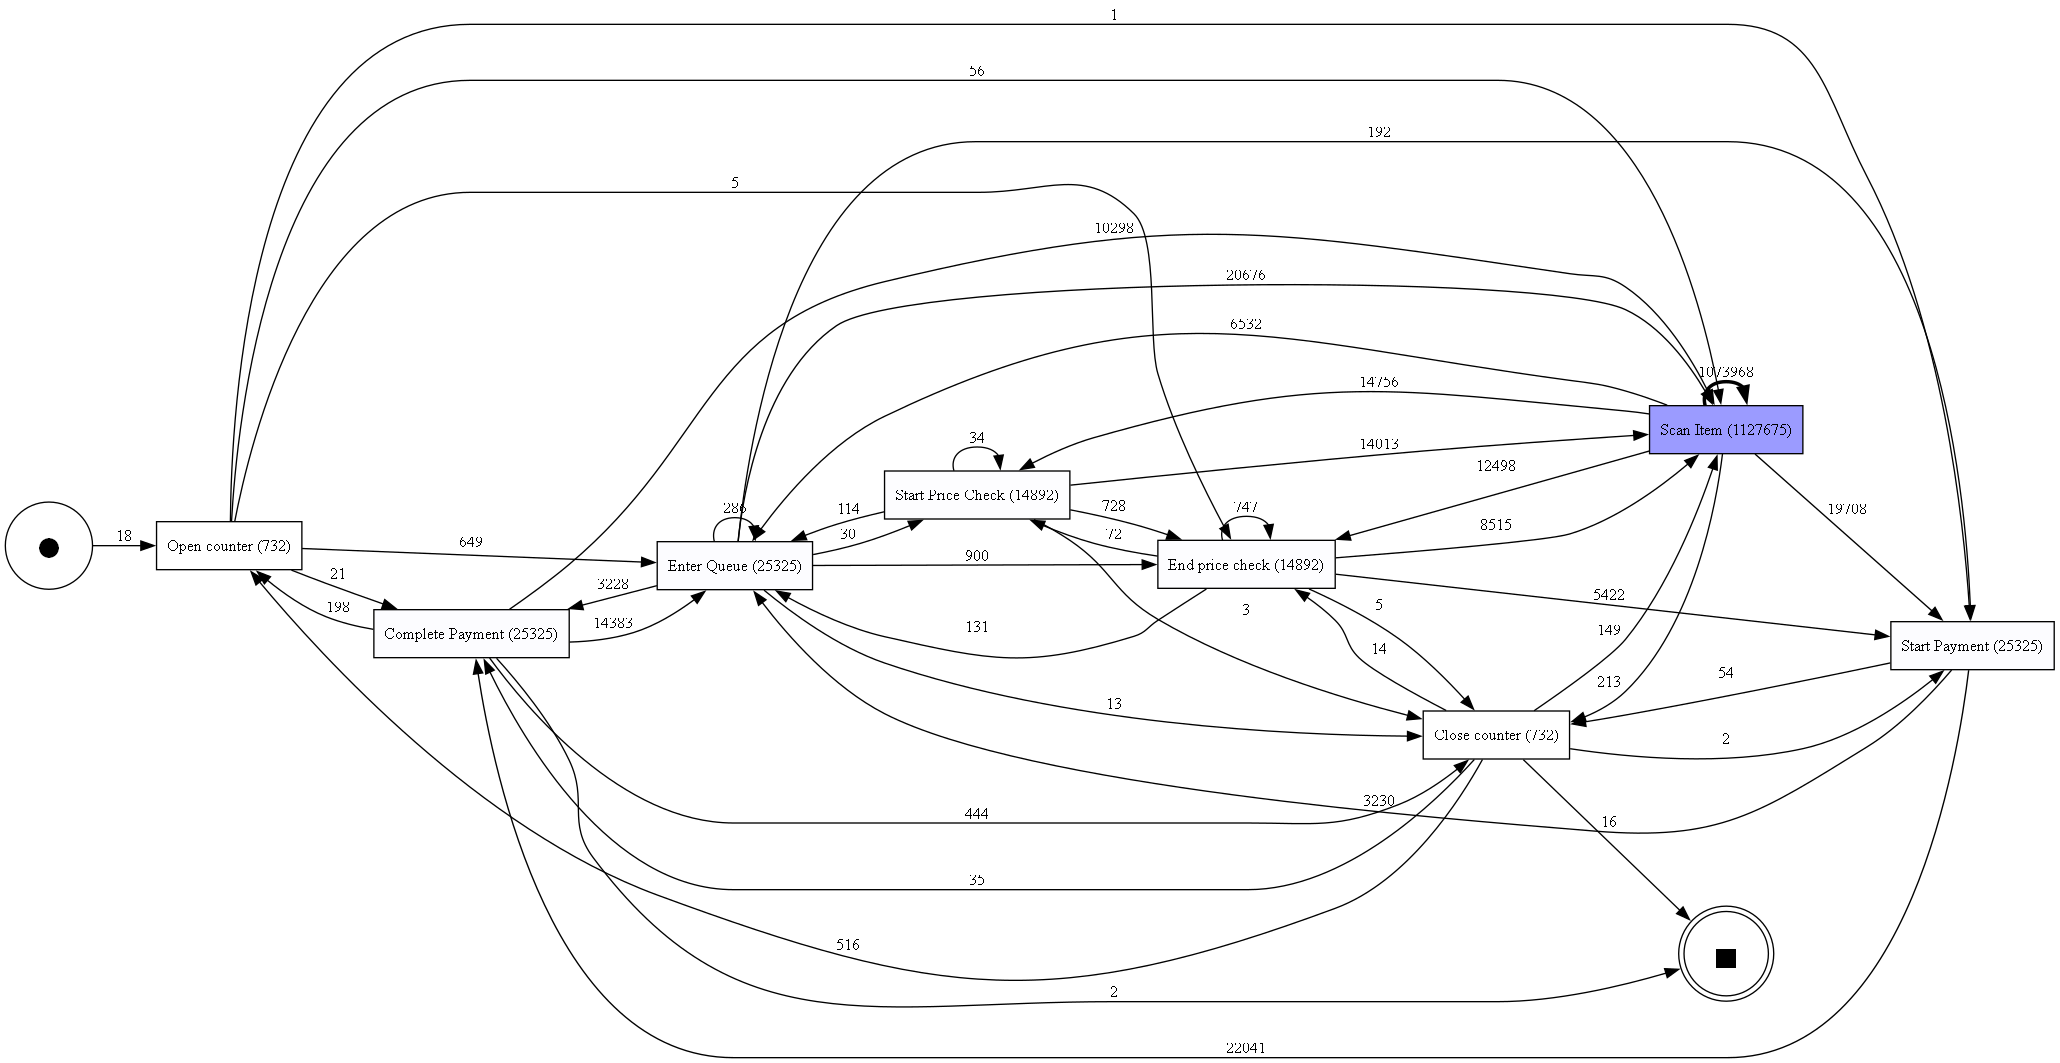

Generating DFG for: Customer Perspective
File: Supermarket_Customer.xes


parsing log, completed traces ::   0%|          | 0/9557 [00:00<?, ?it/s]

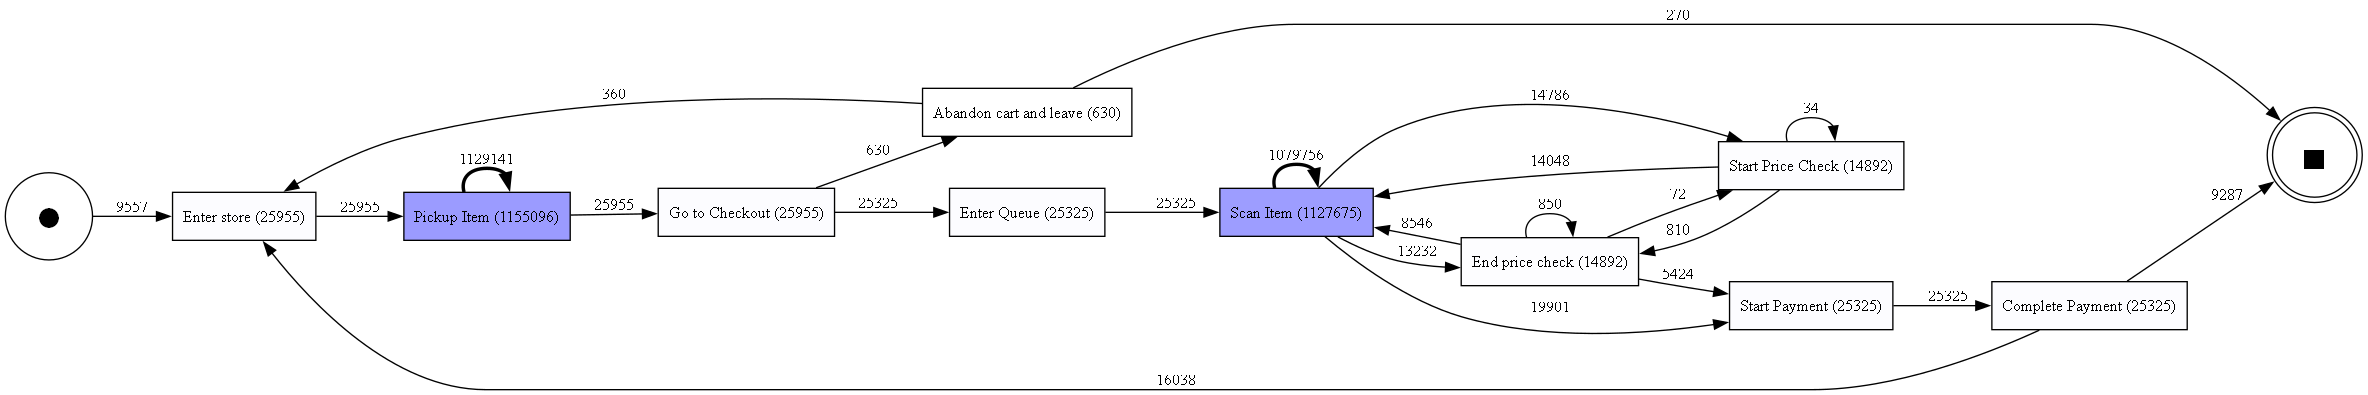

Generating DFG for: Manager Perspective
File: Supermarket_Manager.xes


parsing log, completed traces ::   0%|          | 0/2 [00:00<?, ?it/s]

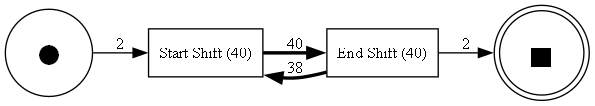

In [14]:
import pm4py

# Group the logs you already imported into a dictionary for easy looping
import pm4py
from pm4py.objects.log.importer.xes import importer as xes_importer

# 1. Map the exact file paths to their perspective names
log_files = {
    "Cashier Perspective": "Supermarket_Cashier.xes",
    "Clerk Perspective": "Supermarket_Clerk.xes",
    "Counter Perspective": "Supermarket_Counter.xes",
    "Customer Perspective": "Supermarket_Customer.xes",
    "Manager Perspective": "Supermarket_Manager.xes"
}

# 2. Loop through, import fresh, and visualize the DFG immediately
for name, file_path in log_files.items():
    print(f"==================================================")
    print(f"Generating DFG for: {name}")
    print(f"File: {file_path}")
    print(f"==================================================")
    
    # Import the log fresh from the file
    current_log = xes_importer.apply(file_path)
    
    # Discover the Directly-Follows Graph (DFG)
    dfg, start_activities, end_activities = pm4py.discover_dfg(current_log)
    
    # Visualize the generated DFG
    pm4py.view_dfg(dfg, start_activities, end_activities)


## Other things to consider when working with XES logs

- Missing or inconsistent timestamps
- Multiple events with identical timestamps
- Multiple lifecycle events (start / complete)
- Very large logs that do not fit in memory
- Assuming every case follows the same path

Always *inspect before modeling*.
